# Import libraries

In [46]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

# Load data

In [47]:
LOAD_PATH = Path("../data/data.parquet")
data = pd.read_parquet(LOAD_PATH)
print("\nShape of data:", data.shape)
data.head()


Shape of data: (8120, 31)


,value,coordinates,period.label,period.interval,period.datetime_from.utc,period.datetime_from.local,period.datetime_to.utc,period.datetime_to.local,parameter.id,parameter.name,...,coverage.expected_count,coverage.expected_interval,coverage.observed_count,coverage.observed_interval,coverage.percent_complete,coverage.percent_coverage,coverage.datetime_from.utc,coverage.datetime_from.local,coverage.datetime_to.utc,coverage.datetime_to.local
0,22.9,None,1hour,01:00:00,2026-01-05T07:00:00Z,2026-01-05T08:00:00+01:00,2026-01-05T08:00:00Z,2026-01-05T09:00:00+01:00,19,pm1,...,1,01:00:00,1,01:00:00,100.0,100.0,2026-01-05T07:00:00Z,2026-01-05T08:00:00+01:00,2026-01-05T08:00:00Z,2026-01-05T09:00:00+01:00
1,26.4,None,1hour,01:00:00,2026-01-05T08:00:00Z,2026-01-05T09:00:00+01:00,2026-01-05T09:00:00Z,2026-01-05T10:00:00+01:00,19,pm1,...,1,01:00:00,1,01:00:00,100.0,100.0,2026-01-05T08:00:00Z,2026-01-05T09:00:00+01:00,2026-01-05T09:00:00Z,2026-01-05T10:00:00+01:00
2,21.9,None,1hour,01:00:00,2026-01-05T09:00:00Z,2026-01-05T10:00:00+01:00,2026-01-05T10:00:00Z,2026-01-05T11:00:00+01:00,19,pm1,...,1,01:00:00,1,01:00:00,100.0,100.0,2026-01-05T09:00:00Z,2026-01-05T10:00:00+01:00,2026-01-05T10:00:00Z,2026-01-05T11:00:00+01:00
3,23.0,None,1hour,01:00:00,2026-01-05T10:00:00Z,2026-01-05T11:00:00+01:00,2026-01-05T11:00:00Z,2026-01-05T12:00:00+01:00,19,pm1,...,1,01:00:00,1,01:00:00,100.0,100.0,2026-01-05T10:00:00Z,2026-01-05T11:00:00+01:00,2026-01-05T11:00:00Z,2026-01-05T12:00:00+01:00
4,19.1,None,1hour,01:00:00,2026-01-05T11:00:00Z,2026-01-05T12:00:00+01:00,2026-01-05T12:00:00Z,2026-01-05T13:00:00+01:00,19,pm1,...,1,01:00:00,1,01:00:00,100.0,100.0,2026-01-05T11:00:00Z,2026-01-05T12:00:00+01:00,2026-01-05T12:00:00Z,2026-01-05T13:00:00+01:00


In [48]:
df = data.pivot(
    columns="parameter.name",
    index="period.datetime_from.local",
    values="value"
).reset_index().copy()

In [49]:
df = df.rename(columns={
    "period.datetime_from.local": "timestamp",
})

In [50]:
df = df.loc[:, ["timestamp", "pm25", "relativehumidity", "temperature"]]

# Feature engineering

## Date features

In [51]:
def is_weekend(day_of_week: int) -> int:
    match day_of_week:
        case 0 | 7:
            return 1
        case _:
            return 0

In [52]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['year'] = df['timestamp'].dt.year
df['month'] = df['timestamp'].dt.month
df['day_of_week'] = df['timestamp'].dt.day_of_week
df['hour_of_day'] = df['timestamp'].dt.hour
df['is_weekend'] = df['day_of_week'].apply(lambda day: is_weekend(day))
df['hour_sin'] = np.sin(2 * np.pi * df['hour_of_day'] / 24)
df['hour_cos'] = np.cos(2 * np.pi * df['hour_of_day'] / 24)
df['month_sin'] = np.sin(2* np.pi * df['month'] / 12)
df['month_cos'] = np.cos(2* np.pi * df['month'] / 12)
df['day_sin'] = np.sin(2 * np.pi * df['day_of_week'] / 7)
df['day_cos'] = np.cos(2 * np.pi * df['day_of_week'] / 7)

## Rolling & lag

In [53]:
target = 'pm25'
lag_periods = [3, 6, 9, 12]
rolling_window = [12]

In [54]:
for window in rolling_window:
    df[f'rolling_{target}_{str(window)}'] = df[target].rolling(window=window).mean()

for period in lag_periods:
    df[f'lag_{target}_{str(period)}'] = df[target].shift(periods=period)

## Shifted target

In [55]:
df['target'] = df[target].shift(-3)

In [56]:
df = df.dropna()

# Create data splits

In [57]:
train_idx = int(np.ceil(len(df) * .9))

In [58]:
train_df = df.loc[:train_idx, :]
test_df = df.loc[train_idx:, :]

In [59]:
X_train = train_df.drop(['timestamp', 'target'], axis=1)
y_train = train_df.loc[:, 'target']

X_test = test_df.drop(['timestamp', 'target'], axis=1)
y_test = test_df.loc[:, 'target']

train_timestamp = train_df.loc[:, 'timestamp']
test_timestamp = test_df.loc[:, 'timestamp']

# Train model

## Baseline (Ridge)

In [60]:
clf = Ridge(alpha=1.0)
clf.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [61]:
y_hat = clf.predict(X_test)
mae = mean_absolute_error(y_test, y_hat)
r2 = r2_score(y_test, y_hat)

print("MAE", mae)
print("r2", r2)

MAE 4.896902677960352
r2 0.8687292458791991


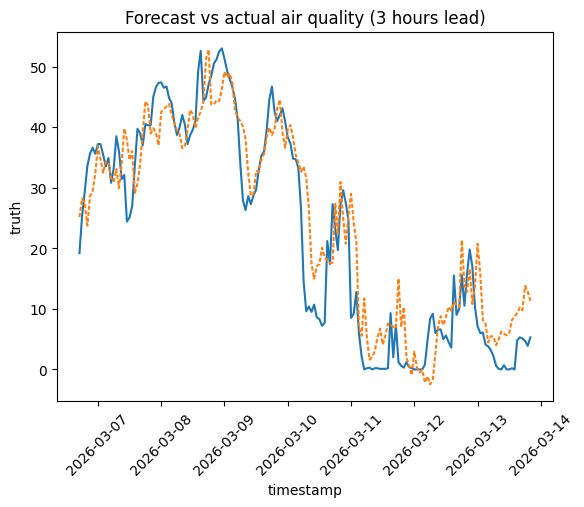

In [86]:
y_hat_df = pd.DataFrame(
    data={
        "timestamp": test_timestamp,
        "truth": y_test,
        "pred": y_hat
    }
)

sns.lineplot(y_hat_df, x="timestamp", y="truth")
sns.lineplot(y_hat_df, x="timestamp", y="pred", dashes=[2, 1])

plt.title("Forecast vs actual air quality (3 hours lead)")
plt.xticks(rotation=45)
plt.show()

In [63]:
y_hat_df.head()

,timestamp,truth,pred
1449,2026-03-06 17:00:00+01:00,19.2,25.148395
1450,2026-03-06 18:00:00+01:00,25.3,28.229950
1451,2026-03-06 19:00:00+01:00,29.3,27.400103
1452,2026-03-06 20:00:00+01:00,33.6,23.758371
1453,2026-03-06 21:00:00+01:00,35.6,28.590682


In [64]:
pd.DataFrame(data={
    "coef": clf.coef_,
    "feature": clf.feature_names_in_
}) \
    .sort_values('coef', ascending=False) \
    .reset_index() \
    .drop('index', axis=1)

,coef,feature
0,0.972158,pm25
1,0.436383,month
2,0.226780,lag_pm25_9
3,0.111540,lag_pm25_6
4,0.102986,day_cos
5,0.000000,year
6,-0.021458,lag_pm25_12
7,-0.043678,lag_pm25_3
8,-0.106777,hour_of_day
9,-0.203222,relativehumidity


In [65]:
df.groupby('month').agg({
    'target': 'mean'
})

parameter.name,target
month,
1,30.788803
2,16.941402
3,26.351456


# Final remarks
At the end of this experiment, we observe the following:
- Removing lag and rolling features makes model **useless** (worth than guessing)
- As such, current features (temperature, humidity and temporal features) **do not** have significant explanatory power.
- Further feature engineering is required. Likely candidates:
    - Wind
    - Pressure

# Prophet

In [66]:
from prophet import Prophet

In [74]:
prophet_df = df.loc[:, ["timestamp", "pm25"]]
prophet_df = prophet_df.rename(columns={"timestamp":"ds", "pm25":"y"})

In [77]:
prophet_df['ds'] = prophet_df['ds'].dt.tz_localize(None)

In [78]:
m = Prophet()
m.fit(prophet_df)

23:41:37 - cmdstanpy - INFO - Chain [1] start processing
23:41:37 - cmdstanpy - INFO - Chain [1] done processing


In [79]:
# Python
future = m.make_future_dataframe(periods=48)
future.tail()

,ds
1652,2026-04-26 20:00:00
1653,2026-04-27 20:00:00
1654,2026-04-28 20:00:00
1655,2026-04-29 20:00:00
1656,2026-04-30 20:00:00


In [80]:
forecast = m.predict(future)
forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
1652,2026-04-26 20:00:00,63.447945,18.570808,107.633758
1653,2026-04-27 20:00:00,59.701718,10.714058,109.796093
1654,2026-04-28 20:00:00,65.166901,17.447445,115.355699
1655,2026-04-29 20:00:00,63.983307,12.260863,117.586884
1656,2026-04-30 20:00:00,63.429511,10.556301,116.789062


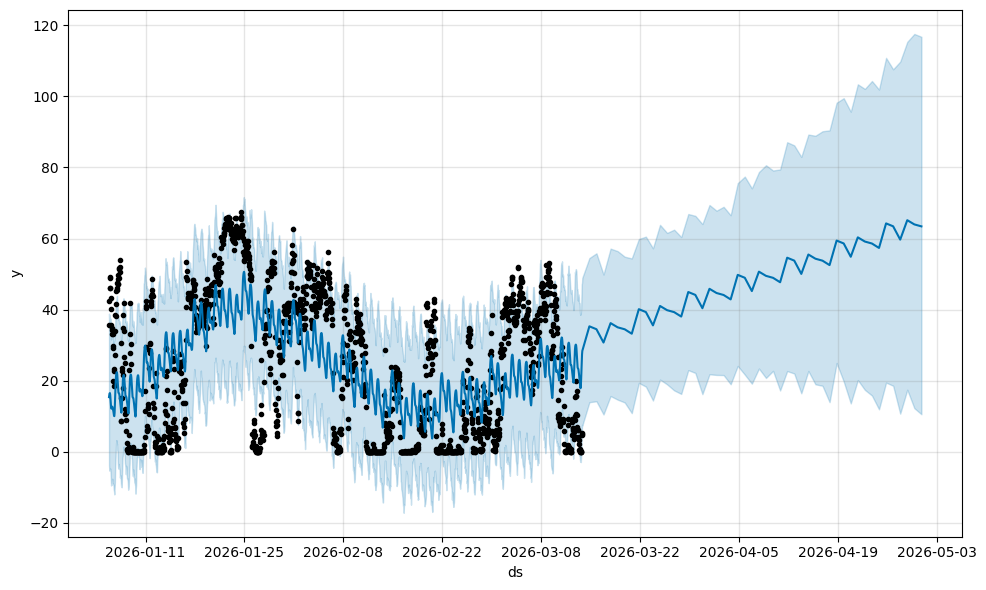

In [81]:
fig1 = m.plot(forecast)

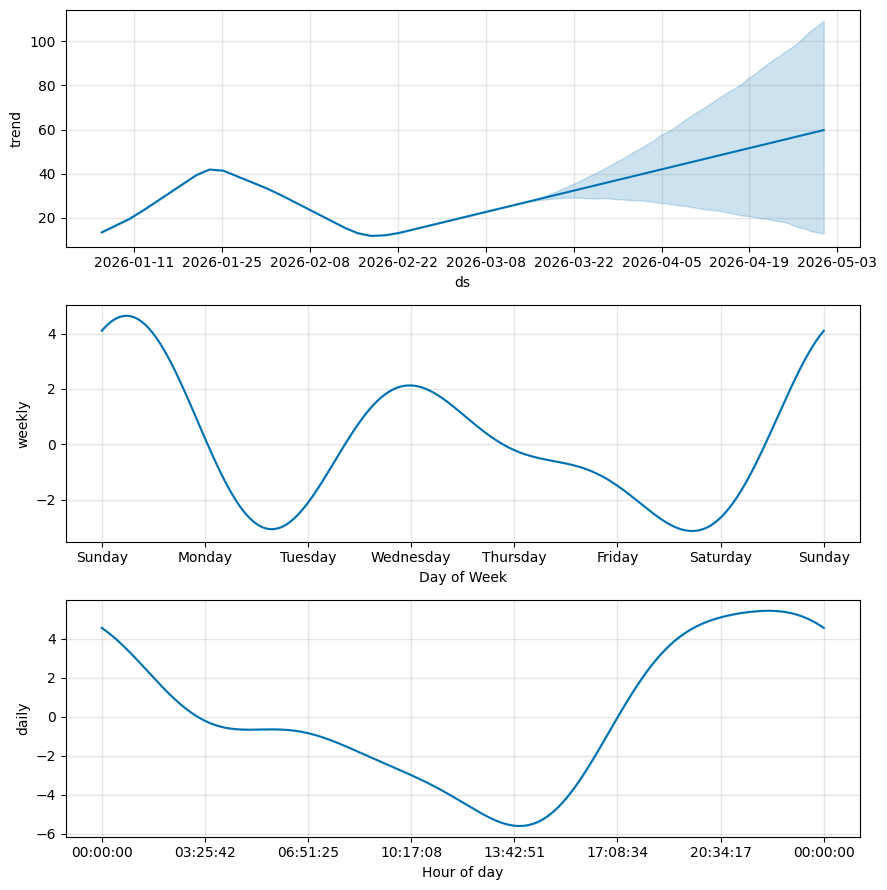

In [82]:
fig2 = m.plot_components(forecast)